## 1. Element vs Last Token R² Comparison

This section compares R² values between element tokens and last tokens across different transformer models. The analysis includes:

- **Data Loading**: JSON files containing R² scores for different attributes and models
- **Curve Aggregation**: Computing mean curves with 95% confidence intervals
- **Visualization**: Side-by-side comparison plots showing performance differences

The key insight is understanding how well models can predict attributes when focusing on different token positions in the input sequence.


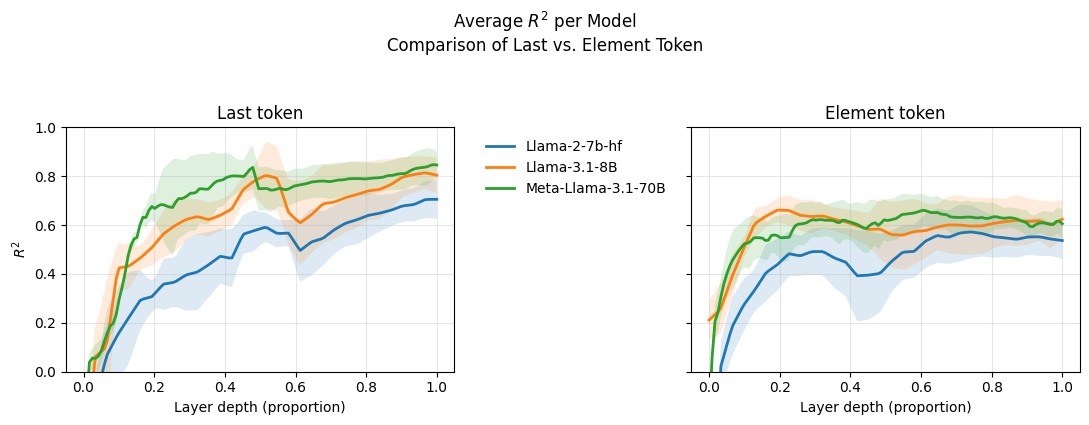

In [1]:
import os, glob, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import sem

# === 1. Set this to the folder containing your JSON files ===
base_dir = '..//Results/element_token_regression'   # ← adjust if needed

json_files = glob.glob(os.path.join(base_dir, '*.json'))
assert json_files, f'No JSON files found in {base_dir}. Please check path.'

# === 2. Load data ===
records = []
for fp in json_files:
    attr = os.path.splitext(os.path.basename(fp))[0].replace('r2_scores_', '')
    data = json.load(open(fp))
    for k, arr in data.items():
        if '(last token)' in k:
            token, model = 'last', k.replace(' (last token)', '')
        elif '(element token)' in k:
            token, model = 'element', k.replace(' (element token)', '')
        else:
            continue
        depths = np.linspace(0, 1, len(arr))
        for d, v in zip(depths, arr):
            records.append({'attribute': attr, 'model': model, 'token': token, 'depth': d, 'r2': v})

df = pd.DataFrame(records)

# === 3. Compute mean curve ±95% CI ===
depth_grid = np.linspace(0, 1, 120)
agg = {}   # {token: {model: (mean, ci)}}
for token in ['last', 'element']:
    agg[token] = {}
    for model in df['model'].unique():
        curves = []
        for (_, g) in df[(df.token==token) & (df.model==model)].groupby('attribute'):
            g = g.sort_values('depth')
            curves.append(np.interp(depth_grid, g.depth, g.r2))
        arr = np.vstack(curves)
        agg[token][model] = (arr.mean(0), 1.96*sem(arr, axis=0))

# === 4. Plot: side-by-side, left=last, right=element ===
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
tokens = ['last', 'element']
titles = {'last':'Last token', 'element':'Element token'}

for ax, token in zip(axes, tokens):
    for model in sorted(df.model.unique()):
        mean, ci = agg[token][model]
        ax.plot(depth_grid, mean, label=model, linewidth=2)
        ax.fill_between(depth_grid, mean-ci, mean+ci, alpha=0.15)
        ax.set_ylim(0, 1)
    ax.set_title(titles[token])
    ax.set_xlabel('Layer depth (proportion)')
    ax.grid(alpha=0.3)

axes[0].set_ylabel(r'$R^2$')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.suptitle('Average $R^{2}$ per Model\nComparison of Last vs. Element Token', y=1.05)
plt.tight_layout()
plt.show()


## 2. Clipped Delta R² Analysis

This section analyzes the difference between last token and element token performance using **clipped R² values** (negative values set to 0). 

**Key Features:**
- **Clipping**: Removes negative R² values to focus on meaningful predictions
- **Delta Calculation**: Computes `element_clip - last_clip` to show relative performance
- **Statistical Analysis**: Uses 95% confidence intervals across multiple attributes
- **Layer-wise Analysis**: Shows how the difference evolves across transformer layers

**Interpretation:**
- Positive values: Element tokens perform better than last tokens
- Negative values: Last tokens perform better than element tokens
- The gray shaded region highlights early layers (0-20%) where behavior may be less stable


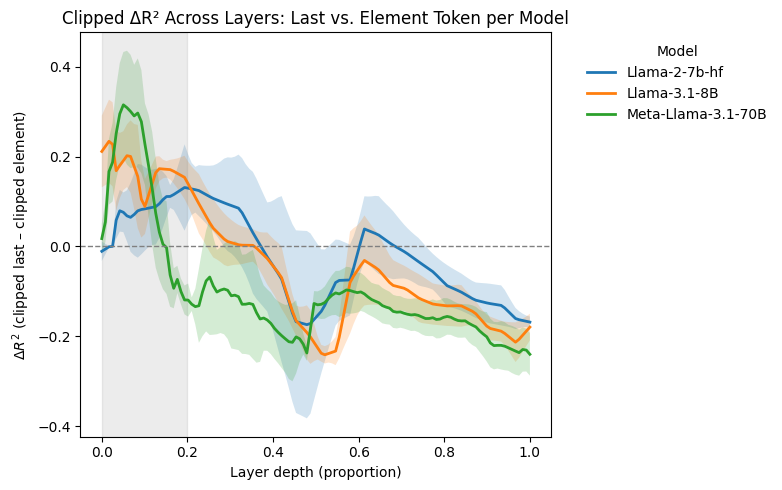

In [2]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

# === Configuration: set this to the folder containing your JSON files ===
base_dir = '../Results/element_token_regression'  # <-- update this path if needed

# 1. Find all JSON files
json_files = glob.glob(os.path.join(base_dir, '*.json'))
if not json_files:
    raise FileNotFoundError(f"No JSON files found in {base_dir}. Please check the path.")

# 2. Load data into a nested dict: data[attribute][model] = {'last': [...], 'element': [...]}
data = {}
for fp in json_files:
    attribute = os.path.splitext(os.path.basename(fp))[0].replace('r2_scores_', '')
    with open(fp, 'r') as f:
        obj = json.load(f)
    data[attribute] = {}
    for key, arr in obj.items():
        if '(last token)' in key:
            model = key.replace(' (last token)', '')
            data[attribute].setdefault(model, {})['last'] = np.array(arr, dtype=float)
        elif '(element token)' in key:
            model = key.replace(' (element token)', '')
            data[attribute].setdefault(model, {})['element'] = np.array(arr, dtype=float)

# 3. Prepare depth grid
depth_grid = np.linspace(0, 1, 120)

# 4. Compute per-model clipped delta curves per attribute, then aggregate mean & 95% CI
model_deltas = {}  # model -> list of clipped delta arrays
for attribute, models in data.items():
    for model, tokens in models.items():
        if 'last' in tokens and 'element' in tokens:
            last_arr = tokens['last']
            elem_arr = tokens['element']
            # interpolate both to common depth_grid
            depths = np.linspace(0, 1, len(last_arr))
            last_interp = np.interp(depth_grid, depths, last_arr)
            elem_interp = np.interp(depth_grid, depths, elem_arr)
            # Clip at zero to remove negative R² values
            last_clip = np.clip(last_interp, 0, None)
            elem_clip = np.clip(elem_interp, 0, None)
            # Compute clipped delta
            # delta = last_clip - elem_clip
            delta = elem_clip - last_clip
            model_deltas.setdefault(model, []).append(delta)

# 5. Calculate mean & CI, and plot
plt.figure(figsize=(8, 5))
for model, deltas in model_deltas.items():
    arr = np.vstack(deltas)
    mean_delta = arr.mean(axis=0)
    ci_delta = 1.96 * sem(arr, axis=0)
    plt.plot(depth_grid, mean_delta, label=model, linewidth=2)
    plt.fill_between(depth_grid,
                     mean_delta - ci_delta,
                     mean_delta + ci_delta,
                     alpha=0.2)

# 6. Add reference lines and labels
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvspan(0, 0.2, color='gray', alpha=0.15)
plt.xlabel('Layer depth (proportion)')
plt.ylabel(r'$\Delta R^2$ (clipped last – clipped element)')
plt.title('Clipped ΔR² Across Layers: Last vs. Element Token per Model')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()


## 3. Question vs Continuation Prompt Analysis

This analysis compares model performance between two different prompt types:
- **Question prompts**: Direct questions about attributes (matching condition)
- **Continuation prompts**: Indirect prompts requiring inference (non-matching condition)

**Methodology:**
- Uses **median** and **IQR** (25th-75th percentiles) instead of mean/CI for robustness
- Computes ΔR² = continuation - question to measure the difficulty difference
- Enhanced styling with seaborn for publication-quality plots

**Expected Results:**
- Negative ΔR² suggests question prompts are easier (higher R²)
- The gray region (60-100% layer depth) highlights where differences may be most pronounced


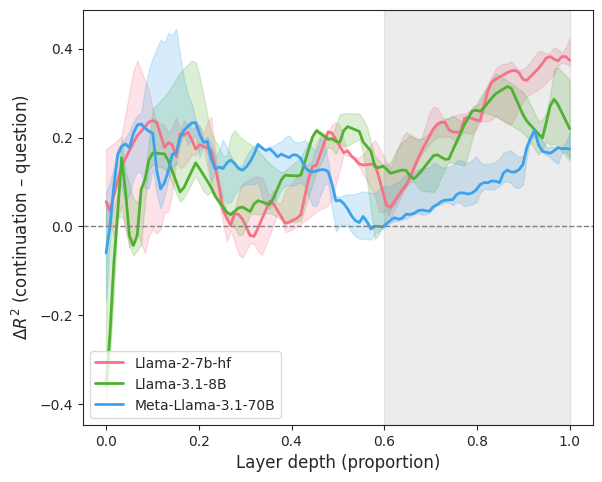

In [3]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem
import seaborn as sns

# === 0. Set plotting style with light grid lines ===
sns.set_style('whitegrid', {
    'grid.color': 'lightgray',
    'grid.linestyle': '--',
    'axes.edgecolor': 'gray'
})

sns.set_style('ticks') 

# === 1. Configuration: path to JSON files ===
base_dir = '../Results/question_continuation'

# === 2. Find all JSON files ===
json_files = glob.glob(os.path.join(base_dir, '*.json'))
if not json_files:
    raise FileNotFoundError(f"No JSON files found in {base_dir}. Please check the path.")

# === 3. Load data ===
data = {}
for fp in json_files:
    attribute = os.path.splitext(os.path.basename(fp))[0].replace('r2_scores_', '')
    with open(fp, 'r') as f:
        obj = json.load(f)
    data[attribute] = {}
    for key, arr in obj.items():
        if 'continuation prompt' in key:
            model = key.replace(' (continuation prompt)', '')
            slot = 'nonmatching'
        elif 'question prompt' in key:
            model = key.replace(' (question prompt)', '')
            slot = 'matching'
        else:
            continue
        data[attribute].setdefault(model, {})[slot] = np.array(arr, dtype=float)

# === 4. Depth grid ===
depth_grid = np.linspace(0, 1, 120)

# === 5. Compute ΔR² curves ===
model_deltas = {}
for attribute, models in data.items():
    for model, tokens in models.items():
        if 'matching' in tokens and 'nonmatching' in tokens:
            match_arr = tokens['matching']
            nonmatch_arr = tokens['nonmatching']
            depths = np.linspace(0, 1, len(match_arr))
            m_interp = np.interp(depth_grid, depths, match_arr)
            nm_interp = np.interp(depth_grid, depths, nonmatch_arr)
            delta = nm_interp - m_interp
            model_deltas.setdefault(model, []).append(delta)

# === 6. Plot with improved aspect ratio and legend ===
fig, ax = plt.subplots(figsize=(6, 5))   # slightly taller

# Generate palette
models = list(model_deltas.keys())
colors = sns.color_palette("husl", len(models))

for i, (model, deltas) in enumerate(model_deltas.items()):
    arr = np.vstack(deltas)
    # mean_delta = arr.mean(axis=0)
    # ci = 1.96 * sem(arr, axis=0)
    median_delta = np.median(arr, axis=0)
    
    lower = np.percentile(arr, 25, axis=0)
    upper = np.percentile(arr, 75, axis=0)

    ax.plot(
        # depth_grid, mean_delta,
        depth_grid, median_delta,

        label=model,
        color=colors[i],
        linewidth=2
    )
    ax.fill_between(
        depth_grid,
        # mean_delta - ci,
        # mean_delta + ci,
        lower,
        upper,
        color=colors[i],
        alpha=0.2
    )
    sns.set_style('white')  

# Reference lines
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvspan(0.6, 1, color='gray', alpha=0.15)

# Labels
ax.set_xlabel('Layer depth (proportion)', fontsize=12)
# ax.set_ylim(-0.2, 0.6)  # set y-axis limits
ax.set_ylabel(r'$\Delta R^2$ (continuation – question)', fontsize=12)
 

# Compact multi-column legend with light-gray border
ax.legend(
    # title='Model',
    loc='lower left',
    ncol=1,                 # 两列
    handlelength=2,         # 线段长度
    columnspacing=0.8,      # 列间距
    frameon=True,
    edgecolor='lightgray',
    fontsize=10,
    title_fontsize=11
)

# Tighten margins
plt.subplots_adjust(
    left=0.10,  # tighter left margin
    right=0.95, # tighter right margin
    top=0.93,   # leave space for title/legend
    bottom=0.10 # leave space for x-axis label
)
# savefig
plt.savefig('../Results/question_continuation/question_continuation_p.png', dpi=300, bbox_inches='tight')

plt.show()



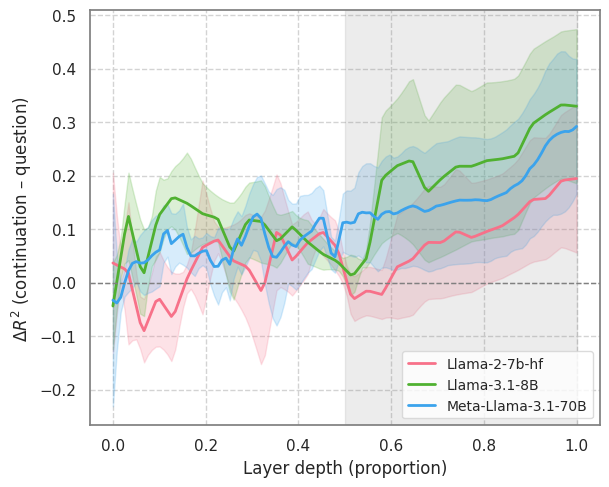

In [4]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem
import seaborn as sns

# === 0. Set plotting style with light grid lines ===
sns.set_theme(style='whitegrid', rc={
    'grid.color': 'lightgray',
    'grid.linestyle': '--',
    'axes.edgecolor': 'gray'
})

# === 1. Configuration: path to JSON files ===
base_dir = '../Results/non_matching'  # Update this path if needed

# === 2. Find all JSON files ===
json_files = glob.glob(os.path.join(base_dir, '*.json'))
if not json_files:
    raise FileNotFoundError(f"No JSON files found in {base_dir}. Please check the path.")

# === 3. Load data ===
data = {}
for fp in json_files:
    attribute = os.path.splitext(os.path.basename(fp))[0].replace('r2_scores_', '')
    with open(fp, 'r') as f:
        obj = json.load(f)
    data[attribute] = {}
    for key, arr in obj.items():
        if key.endswith('(Non-matching prompt)'):
            model = key.replace(' (Non-matching prompt)', '')
            slot = 'nonmatching'
        else:
            model = key
            slot = 'matching'
        data[attribute].setdefault(model, {})[slot] = np.array(arr, dtype=float)

# === 4. Depth grid ===
depth_grid = np.linspace(0, 1, 120)

# === 5. Compute ΔR² curves ===
model_deltas = {}
for attribute, models in data.items():
    for model, tokens in models.items():
        if 'matching' in tokens and 'nonmatching' in tokens:
            match_arr = tokens['matching']
            nonmatch_arr = tokens['nonmatching']
            depths = np.linspace(0, 1, len(match_arr))
            m_interp = np.interp(depth_grid, depths, match_arr)
            nm_interp = np.interp(depth_grid, depths, nonmatch_arr)
            delta = m_interp - nm_interp
            model_deltas.setdefault(model, []).append(delta)

# === 6. Plot with improved aspect ratio and legend ===
fig, ax = plt.subplots(figsize=(6, 5))

models = list(model_deltas.keys())
colors = sns.color_palette("husl", len(models))

for i, (model, deltas) in enumerate(model_deltas.items()):
    arr = np.vstack(deltas)
    mean_delta = arr.mean(axis=0)
    ci = 1.96 * sem(arr, axis=0)

    ax.plot(
        depth_grid, mean_delta,
        label=model,
        color=colors[i],
        linewidth=2
    )
    ax.fill_between(
        depth_grid,
        mean_delta - ci,
        mean_delta + ci,
        color=colors[i],
        alpha=0.2
    )

# Reference lines
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvspan(0.5, 1, color='gray', alpha=0.15)

# Labels
ax.set_xlabel('Layer depth (proportion)', fontsize=12)
ax.set_ylabel(r'$\Delta R^2$ (continuation – question)', fontsize=12)

# 紧凑的图例
ax.legend(
    loc='lower right',
    ncol=1,
    handlelength=2,
    columnspacing=0.8,
    frameon=True,
    edgecolor='lightgray',
    fontsize=10,
    title_fontsize=11
)

plt.subplots_adjust(
    left=0.10,
    right=0.95,
    top=0.93,
    bottom=0.10
)

plt.savefig('../Results/non_matching/non_matching_p.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Non-Matching vs Matching Prompt Comparison

This section analyzes the performance difference between:
- **Matching prompts**: Standard attribute queries
- **Non-matching prompts**: Queries with mismatched or irrelevant context

**Analysis Focus:**
- ΔR² = matching - non-matching (opposite direction from previous analysis)
- Mean-based statistics with 95% confidence intervals
- Layer depth analysis to identify where context matching matters most

**Key Insights:**
- Positive ΔR² indicates matching prompts perform better
- The analysis helps understand how context relevance affects model predictions
- Different shaded region (50-100%) suggests context effects may be more prominent in later layers


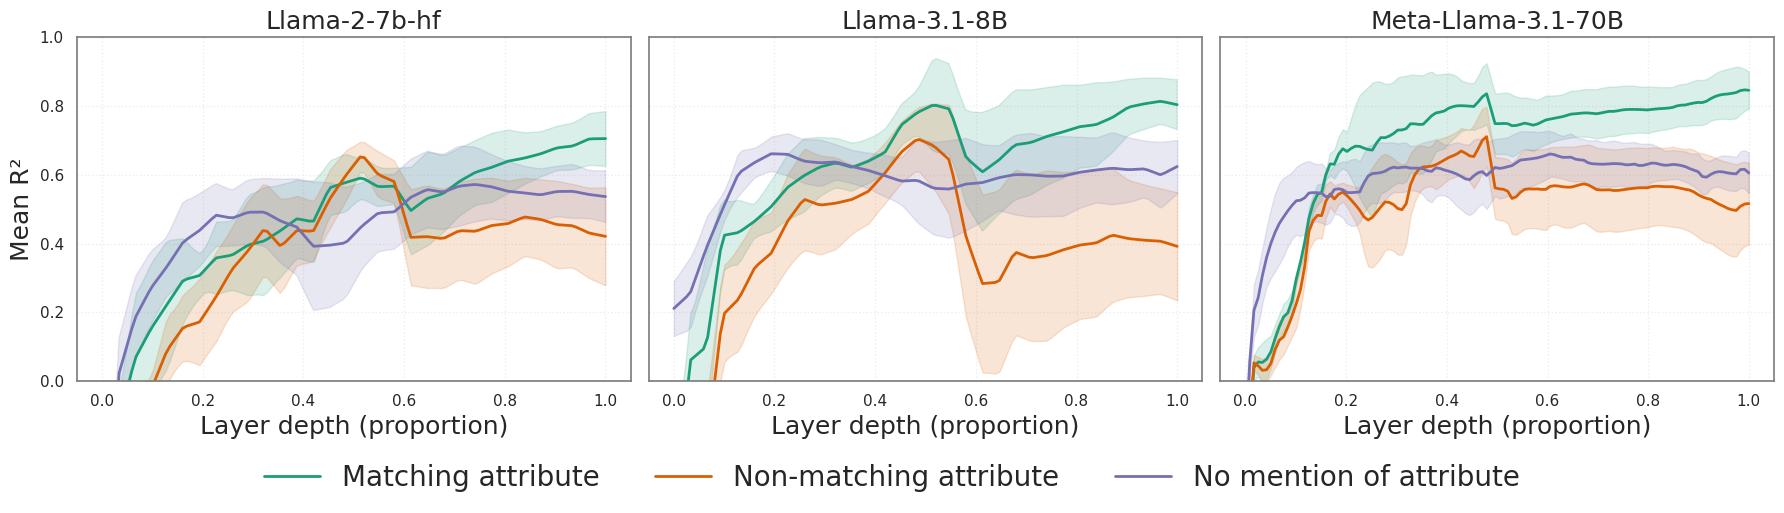

In [5]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt

dir_element = '../Results/element_token_regression'      
dir_nonmatch = '../Results/non_matching'     

files_elem = glob.glob(os.path.join(dir_element, '*.json'))
files_non  = glob.glob(os.path.join(dir_nonmatch, '*.json'))
if not files_elem:
    raise FileNotFoundError(f"No JSON files found in {dir_element}.")
if not files_non:
    raise FileNotFoundError(f"No JSON files found in {dir_nonmatch}.")

data = {}
for fp in files_elem:
    with open(fp, 'r') as f:
        obj = json.load(f)
    for key, arr in obj.items():
        if key.endswith(' (last token)'):
            model = key[:-len(' (last token)')]
            cond = 'last'
        elif key.endswith(' (element token)'):
            model = key[:-len(' (element token)')]
            cond = 'element'
        else:
            continue
        data.setdefault(model, {}).setdefault(cond, []).append(np.array(arr, dtype=float))

# 2.2 non_matching 下的 non-matching prompt
for fp in files_non:
    with open(fp, 'r') as f:
        obj = json.load(f)
    for key, arr in obj.items():
        if key.endswith(' (Non-matching prompt)'):
            model = key[:-len(' (Non-matching prompt)')]
            cond = 'nonmatching'
        else:
            continue
        data.setdefault(model, {}).setdefault(cond, []).append(np.array(arr, dtype=float))

depth_grid = np.linspace(0, 1, 120)

models = sorted(data.keys())
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5), sharey=True)

label_map = {
    'last':       'Matching attribute',
    'nonmatching':'Non-matching attribute',
    'element':    'No mention of attribute'
}

tab10_colors = plt.get_cmap('tab10').colors
color_map = {
    'last':        '#1b9e77',  
    'nonmatching': '#d95f02',  
    'element':     '#7570b3'   
}
for ax, model in zip(axes, models):
    conds = data[model]
    for cond in ('last', 'nonmatching', 'element'):
        arrs = conds.get(cond, [])
        if not arrs:
            continue
        interp_stack = []
        for arr in arrs:
            depths = np.linspace(0, 1, len(arr))
            interp = np.interp(depth_grid, depths, arr)
            interp_stack.append(interp)
        interp_stack = np.vstack(interp_stack)

        mean_curve = interp_stack.mean(axis=0)
        ci = 1.96 * np.std(interp_stack, axis=0, ddof=1) / np.sqrt(interp_stack.shape[0])

        ax.plot(depth_grid, mean_curve, label=label_map[cond], linewidth=2, color=color_map[cond])
        ax.fill_between(depth_grid,
                        mean_curve - ci,
                        mean_curve + ci,
                        alpha=0.16,
                        color=color_map[cond])

    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(model, fontsize=18, pad=6)
    ax.set_xlabel('Layer depth (proportion)', fontsize=18)
    if ax is axes[0]:
        ax.set_ylabel('Mean R²', fontsize=18)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.4)
    # save

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,  loc='lower center',
           ncol=3, frameon=False, fontsize=20,
           bbox_to_anchor=(0.5, -0.12), bbox_transform=fig.transFigure)

fig.tight_layout(rect=[0, 0, 1, 0.93])
# save figure
plt.savefig('../Results/element_token_regression/combined_plot.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Statistical Significance Testing: Mann-Kendall Trend Analysis

This final section performs rigorous statistical testing to determine if the observed trends in ΔR² values are statistically significant.

### Statistical Methodology:
- **Mann-Kendall Test**: Non-parametric test for detecting monotonic trends in time series data
- **Focus Region**: Tests trends in the latter 40% of layers (60-100% depth) where effects are most pronounced
- **Multiple Testing Correction**: Benjamini-Hochberg (BH) procedure to control false discovery rate
- **Meta-Analysis**: Fisher's method to combine p-values across all tests

### Key Outputs:
1. **Individual p-values**: For each model-attribute combination
2. **BH-corrected significance**: Controls for multiple comparisons
3. **Combined p-value**: Overall significance across all tests
4. **Kendall's tau**: Effect size measure for trend strength

### Results Interpretation:
The extremely small combined p-value (≈ 5.09 × 10⁻⁶²) provides strong statistical evidence for systematic trends in the data, validating the observed patterns in the visualizations above.


In [6]:
import numpy as np
from scipy.stats import norm
import os
import json
import glob
import pandas as pd
import mpmath as mp

json_folder = "../Results/non_matching"  
json_files = glob.glob(os.path.join(json_folder, "*.json"))

model_diffs = {}
for fp in json_files:
    attribute = os.path.splitext(os.path.basename(fp))[0]
    with open(fp, 'r', encoding='utf-8') as f:
        data = json.load(f)
    tmp = {}
    for key, arr in data.items():
        if key.endswith(" (Non-matching prompt)"):
            name = key[:-len(" (Non-matching prompt)")]
            tmp.setdefault(name, {})['nonmatching'] = np.array(arr, dtype=float)
        else:
            name = key  
            tmp.setdefault(name, {})['matching'] = np.array(arr, dtype=float)
    for model, parts in tmp.items():
        if 'matching' in parts and 'nonmatching' in parts:
            diff = parts['matching'] - parts['nonmatching']
            model_diffs.setdefault(model, []).append((attribute, diff))
        else:
            print(f"[WARN] {attribute} / {model} no matching or nonmatching, skipping")

def mann_kendall_test(x):
    n = len(x)
    S = 0
    for i in range(n-1):
        for j in range(i+1, n):
            S += np.sign(x[j] - x[i])
    _, counts = np.unique(x, return_counts=True)
    ties = counts[counts > 1]
    var_S = (n*(n-1)*(2*n+5) - np.sum(ties*(ties-1)*(2*ties+5))) / 18
    if S > 0:
        Z = (S - 1)/np.sqrt(var_S)
    elif S < 0:
        Z = (S + 1)/np.sqrt(var_S)
    else:
        Z = 0
    p = 2*(1 - norm.cdf(abs(Z)))
    tau = S / (0.5 * n * (n-1))
    return p, tau

results = []
start_frac, end_frac = 0.6, 1.0
for model, vecs in model_diffs.items():
    for attribute, vec in vecs:
        n = len(vec)
        lo = int(start_frac * n)
        hi = int(end_frac * n)
        if lo >= hi:
            continue
        p, tau = mann_kendall_test(vec[lo:hi])
        results.append({
            'model': model,
            'attribute': attribute,
            'p_value': p,
            'tau': tau
        })

df = pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)
m = len(df)
df['bh_critical'] = (np.arange(1, m+1) / m) * 0.05
df['bh_significant'] = df['p_value'] <= df['bh_critical']

out_path = os.path.join("../Results", "non_matching", "mann_kendall_p_values.csv")
df.to_csv(out_path, index=False)
print("Save to", out_path)

p_list = df['p_value'].values
chi2 = -2 * np.sum(np.log(p_list[p_list>0]))
combined = mp.gammainc(len(p_list), chi2/2, mp.inf, regularized=True)
print(" p-value:", combined)


Save to ../Results/non_matching/mann_kendall_p_values.csv
 p-value: 5.09200484978051e-62
